# Week 7 - Linear classification

Learning contents:
* Least squares for classification
* Perceptron
* Logistic regression
* Extra: multi-class logistic regression

In [76]:
# Dependencies
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA 
import matplotlib.pyplot as plt 
import seaborn as sns; sns.set() # this import just makes the plots prettier
import numpy as np

## Data
We'll be working with a dataset of handwritten digits. 
Let visualise some examples.

In [77]:
# We're using a subset of two classes for now
digits = load_digits(n_class=2)

In [78]:
# Handy plotting functions
x_min, x_max = -40, 40
y_min, y_max = -40, 40

def plot_examples():
    show_num = 4
    _, axes = plt.subplots(1, show_num)
    images_and_labels = list(zip(digits.images, digits.target))
    for ax, (image, label) in zip(axes[:], images_and_labels[:show_num]):
        ax.set_axis_off()
        ax.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
        ax.set_title('Label: %i' % label)

def plot_scatter(data, target, n_class=2):
    plt.scatter(data[:, 0], data[:, 1], c=target, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('rainbow', n_class))
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.colorbar();
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)

def plot_decision_boundary(data, weights):
    weights = weights.flatten()
    intersection = weights[0]
    slope = - weights[1] / weights[2]
    xx = np.linspace(x_min, x_max)
    yy = slope * xx - intersection
    plt.plot(xx, yy, 'k--')
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)


def plot_decision_boundary1(X, targets, weights):
    plt.scatter(X[:, 0], X[:, 1], c=targets, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('rainbow', 2))
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.colorbar()
    plt.xlim(-40, 40)
    plt.ylim(-40, 40)
    
    xx = np.linspace(-40, 40, 400)
    yy = np.linspace(-40, 40, 400)
    XX, YY = np.meshgrid(xx, yy)
    ZZ = np.c_[XX.ravel(), YY.ravel()]
    ZZ = PHI(ZZ)
    preds = np.dot(ZZ, weights.T)
    preds = preds.reshape(XX.shape)
    plt.contourf(XX, YY, preds, levels=[-1, 0, 1], cmap='RdBu_r', alpha=0.5)


def plot_multi_class_decision_boundary(X, targets, weights, n_class=n_class):
    plt.scatter(X[:, 0], X[:, 1], c=targets, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('rainbow', n_class))
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.colorbar()

    xx = np.linspace(-40, 40, 400)
    yy = np.linspace(-40, 40, 400)
    XX, YY = np.meshgrid(xx, yy)
    ZZ = np.c_[np.ones(XX.ravel().shape[0]), XX.ravel(), YY.ravel()]

    for i in range(n_class):
        preds = sigmoid(np.dot(ZZ, weights[i]))
        preds = preds.reshape(XX.shape)
        plt.contour(XX, YY, preds, levels=[0.5], colors='k', alpha=0.5)

    plt.show()

    



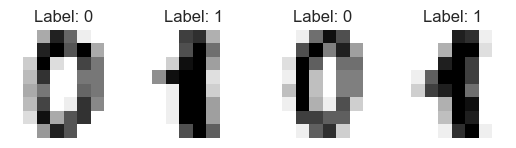

In [79]:
plot_examples()

In [80]:
# The dataset contains 2D data in the form of the `images` attribute, 
# as well as a 1D-version called `data`, where the images have been flattened. 
np.array_equal(digits.images[0].flatten(), digits.data[0])

True

In [81]:
# We can get a 2D version of the data using PCA
pca = PCA(n_components=2)
X = pca.fit_transform(digits.data) # this is the representation, we'll be working with

In [82]:
# Out targets are in the set {0,1}
t_01 = digits.target

/var/folders/65/1n30j6qx5qg79xwsb8vr4v1c0000gn/T/ipykernel_26894/312031313.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.scatter(data[:, 0], data[:, 1], c=target, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('rainbow', n_class))


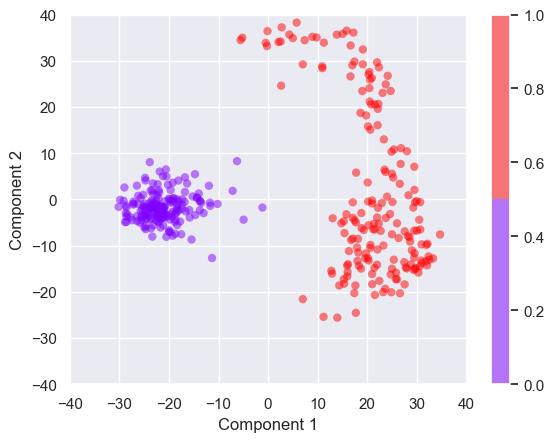

In [83]:
# Let's plot all the data in 2D
plot_scatter(X, t_01)

## 1) Least Squares

### 1.1) Find the weight vector using Least Squares for classification
Find the optimal weights **W** of size (M+1,1), where M is the size of each data point **X_n**={x_1n,...,x_Mn} , in this problem each **X_n** has size 2 because it has 2 coordinates. And where N is the number of data points. To find the optimal weight calculation look at slides 13 and 15 of Lecture 13. Hint: Remember to augment the data with a column of 1's so that the initial weight, **w_0**, can  be multiplied by 1. This means: construct the matrix **X_least_squares** =[1,**x**], where **X** is the matrix of data points, in this case **X** will have dimensions [N x M] (N data points for every vector of M components, in this case with M=2 components/coordinates) and **X_least_squares** will have dimensions [N x M+1] (n datapoints with 2 coordinates and the extra row of 1's to multiply **w_0** by). Note that **X** ranges 1,...,N and each row in **X** ranges from 1 to M.

In [84]:
x_tilda = np.hstack([np.ones((X.shape[0], 1)), X])
x_pseudo_inv = np.linalg.pinv(x_tilda.T @ x_tilda) @ x_tilda.T
w_tilda = np.array(x_pseudo_inv @ t_01)



### 1.2) Create class predictions using the weight vector
Create a function called 'predict' that takes as arguments: the weights vector, **W**, found using the Least Squares method for classification in the previous step, the augmented data created by adding a row of 1's to the data, **X**, and a decision boundary, which will be scalar that will be used to determine the boundary of classification. The function should return the predictions for each data point, so it should return an array of [Nx1] values, based on the decision boundary value for classification. See slide 13, Lecture 13. Finally, check that the predictions are the same than the original target vector.

In [85]:
def predict(x_tilda,w_tilda , boundary = 0.5):    
    y = x_tilda @ w_tilda.T
    pred = np.array([1 if x > boundary else 0 for x in y])
    return pred 

predict(w_tilda,x_tilda)

array([0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,

In [86]:
preds = predict(w_tilda, x_tilda)
np.array_equal(t_01, preds) 

True

### 1.3) Plot the decision boundary 
You can do this either by plotting a line on the boundary or creating a mesh of all predictions. Substitute in the code below **W_least_squares** and **X_least_squares** by the names you have defined them in the previous steps, in order to show the plot.

/var/folders/65/1n30j6qx5qg79xwsb8vr4v1c0000gn/T/ipykernel_26894/312031313.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.scatter(data[:, 0], data[:, 1], c=target, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('rainbow', n_class))


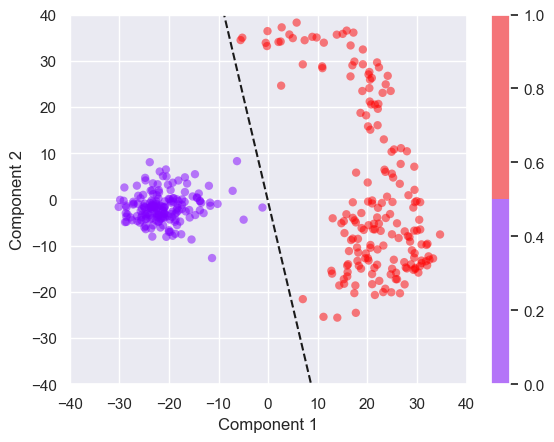

In [87]:
plot_scatter(X, t_01)
plot_decision_boundary(X, w_tilda)

## 2) Perceptron

Implement the perceptron algorithm for classification (see slide 20 of Lecture 13) for 1000 epochs. For this, consider **PHI(X)** as a polynomial basis of order D=2, this means **PHI(X)_n** = { 1, X, X^2 }, so **PHI(X)** will have dimensions [Nx(MxD+1)]. In this case D=2 (polynomial of order 2), M=2 (each data point **X_n** has two coordinates) and N is 360 data points.  Assume that the data is already suffled. To initialize the weight vector **w_0**, we set the random seed to 13 and make that the weight vector is in the range of {-1,1}. In addition, a learning_rate of 0.1 should do the job.
Hint: remember to change the target representation range so that each data point will have a class of -1 or 1.

In [89]:
# Initialize variables
D = 2  # Polynomial order
M = 2  # Each data point has two coordinates
N = X.shape[0]  # Number of data points, adjusted to the actual size of X
learning_rate = 0.1  # Learning rate
epochs = 1000  # Number of epochs

# Polynomial basis function
def PHI(X):
    return np.hstack([np.ones((X.shape[0], 1)), X, X ** 2])

# Convert targets to -1 or 1
targets = np.array([1 if t > 0 else -1 for t in t_01])

# Initialize the weight vector w_0 with random values between -1 and 1
np.random.seed(13)
w = np.random.uniform(-1, 1, M * D + 1)


# Run the Perceptron algorithm
for epoch in range(epochs):
    for j in range(N):
        phi_x = PHI(X[j, :].reshape(1, -1))
        if w.T @ phi_x.T * targets[j] <= 0:
            w = w + learning_rate * phi_x.flatten() * targets[j]



### 2.2) Perform class-predictions
Again, you should be able to classify all correctly by checking that the predictions are the same as the provided target vector. Notice both predictions and target vector are an array of N components of 0's and 1's, so you have to make your predictions go back to 1's and 0's instead of -1's and 1's.

In [90]:
predictions = np.array([1 if w @ PHI(X[i, :].reshape(1, -1)).flatten() > 0 else -1 for i in range(len(X))])
difference = predictions - targets
difference

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

### 2.3) Plot the decision boundary
To plot the decision boundary, adapt the names from your weights and PHI matrix in the code below.

/var/folders/65/1n30j6qx5qg79xwsb8vr4v1c0000gn/T/ipykernel_26894/312031313.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.scatter(X[:, 0], X[:, 1], c=targets, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('rainbow', 2))


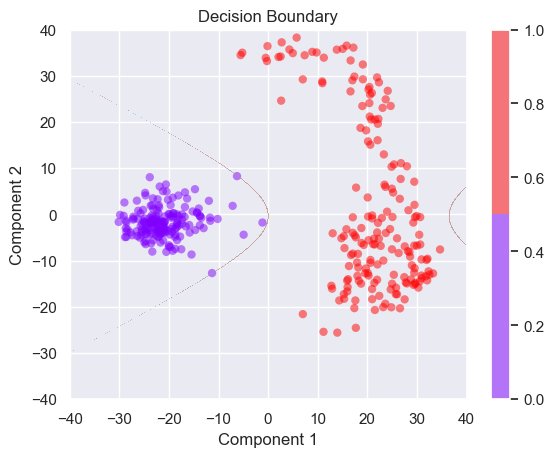

In [91]:
plot_decision_boundary1(X, t_01, w)
plt.title('Decision Boundary')
plt.show()

## 3) Logistic Regression
### 3.1) Find the weight vector using the Logistic Regression
To find the weight vector compute the gradient of error function with respect to **w** , Delta(E(**w**)) (see slide 20 of Lecture 14). **PHI(X)** has dimensions [Nx(M+1)], so it only has an added row of 1's, in this case it has dimension 360x3. And then, considering that **w_0** is provided by initializing it randomly, do, for 30 epochs a weight update: w (tau +1) = w (tau ) − (learning rate) * deltaE (w (tau ))

In [92]:
# initialise W_0 randomly
np.random.seed(42)
W_0 = 2 * np.random.random((1, 3)) -1 # random values in the range [-1,1]

# Our target vectors should be {0, 1}
t_01 = digits.target

In [105]:
def sigmoid(a):
    return 1/(1+np.exp(-a))


def cross_entropy_error(W, X, t):
    y = sigmoid(W @ X.T).flatten()
    return -np.sum(t * np.log(y) + (1 - t) * np.log(1 - y))


def gradient_error(W, X, t):
    y = sigmoid(W @ X.T).flatten()
    yt = (y - t)
    yt = np.broadcast_to(np.expand_dims(yt, axis=1), X.shape)
    return np.sum(yt * X, axis=0)/len(t)


learning_rate = 0.1  # adjust as necessary
num_epochs = 30

for epoch in range(num_epochs):
    gradient = gradient_error(W_0, example_PHI_X, t_01)
    W_0 = W_0 - learning_rate * gradient



### 3.2) Perform class-predictions

In [108]:
predictions = np.array([1 if sigmoid(W_0 @ PHI(X[i, :].reshape(1, -1)).flatten()) > 0.5 else 0 for i in range(len(X))])
difference = predictions - t_01
difference


array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0

### 3.3) Plot the decision boundary
Replace W_logistic and X_logistic with the name of your data.

/var/folders/65/1n30j6qx5qg79xwsb8vr4v1c0000gn/T/ipykernel_26894/312031313.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.scatter(data[:, 0], data[:, 1], c=target, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('rainbow', n_class))
/var/folders/65/1n30j6qx5qg79xwsb8vr4v1c0000gn/T/ipykernel_26894/312031313.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.scatter(X[:, 0], X[:, 1], c=targets, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('rainbow', 2))


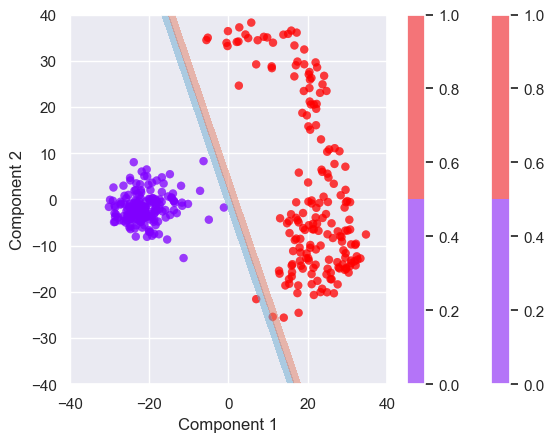

In [107]:
plot_scatter(X, t_01)

# Plot the decision boundary
plot_decision_boundary1(X, t_01, W_0)

plt.show()

## 4) Multi-class logistic regression
Repeat 3) but now for multiple classes, i.e. compute the weight matrix, perform predictions (you shold be able to get about 93% accuracy) and plot decision boundaries.

Hint: You will need to use a one-hot encoding of the targets

In [98]:
# Data
n_class = 3
digits = load_digits(n_class=n_class)
pca = PCA(n_components=2)
X_mult = pca.fit_transform(digits.data)

learning_rate = 0.1

# We need to do a one_hot encoding of our data:
# I.e. 0 -> [1,0,0], 1 -> [0,1,0], 2 -> [0,0,1]
def one_hot(targets, n_class=n_class):
    res = np.eye(n_class)[np.array(targets).reshape(-1)]
    return res.reshape(list(targets.shape)+[n_class])

t_oh = one_hot(digits.target, n_class)

/var/folders/65/1n30j6qx5qg79xwsb8vr4v1c0000gn/T/ipykernel_26894/312031313.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.scatter(data[:, 0], data[:, 1], c=target, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('rainbow', n_class))


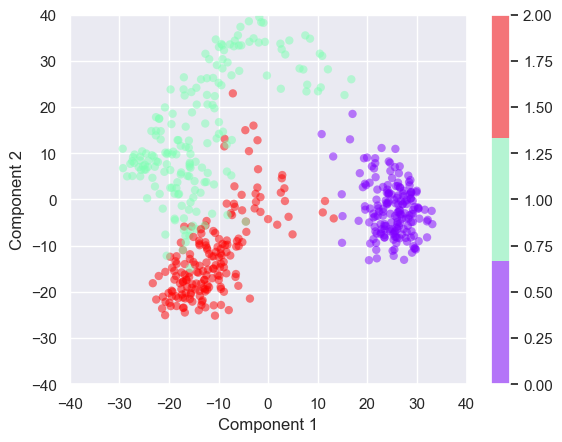

In [99]:
plot_scatter(X_mult, digits.target, n_class=n_class)

Accuracy: 93.30%


/var/folders/65/1n30j6qx5qg79xwsb8vr4v1c0000gn/T/ipykernel_26894/1782139995.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.scatter(X[:, 0], X[:, 1], c=targets, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('rainbow', n_class))


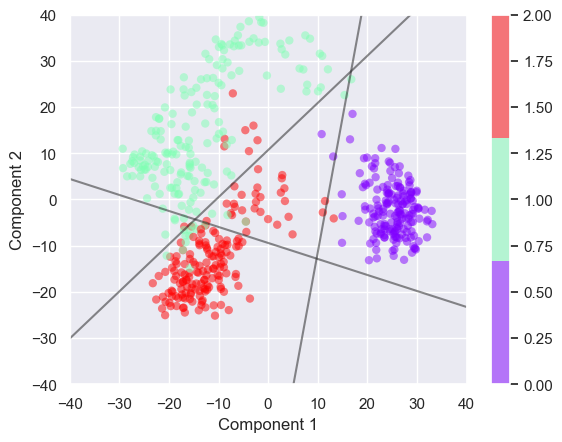

In [101]:
def multi_class_gradient_error(W, X, t_one_hot):
    y = sigmoid(W @ X.T) # This will be matrix with shape (n_class, number_of_samples)
    return ((y - t_one_hot.T) @ X) / X.shape[0]

# Initialize weight matrix
W_mult = np.zeros((n_class, X_mult.shape[1] + 1))
# Add bias term to X_mult
X_mult_bias = np.c_[np.ones(X_mult.shape[0]), X_mult]

# Training
num_epochs = 30000
for epoch in range(num_epochs):
    gradient = multi_class_gradient_error(W_mult, X_mult_bias, t_oh)
    W_mult -= learning_rate * gradient

# Predictions
def multi_class_predict(X, W):
    y_pred = sigmoid(W @ X.T)
    return np.argmax(y_pred, axis=0)

predictions = multi_class_predict(X_mult_bias, W_mult)
accuracy = np.mean(predictions == digits.target) * 100
print(f"Accuracy: {accuracy:.2f}%")


plot_multi_class_decision_boundary(X_mult, digits.target, W_mult)


## 5) (Optional) Multi-class logistic regression on original data representation
Repeat exercise 4), but use the original data representation instead.
You can omit the plots.

Hint: To get 100% accuracy, you can try to:
- Rescale your data to the range [0,1]
- Run 1000 epochs with learning_rate = 0.1